# Importar principales librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

# Path working directory

In [2]:
!pwd

/home/gael/Documents/urban_traffic_data_pipeline/notebooks


# DataBase connection

In [7]:
conn = sqlite3.connect("../data/traffic.db")

query = "SELECT * FROM traffic_metrics"

df = pd.read_sql(query, conn)

df.head(7)

,time,avg_velocity,num_cars,congestion_index,traffic_level
0,0,1.85,20,10.810752,High
1,1,2.10,20,9.523764,Medium
2,2,2.15,20,9.302282,Medium
3,3,2.20,20,9.090868,Medium
4,4,2.65,20,7.547141,Medium
5,5,2.60,20,7.692278,Medium
6,6,2.65,20,7.547141,Medium


# Gráfica de congestión vehícular (CV) como función del tiempo.

* Al inicio la (CV) es alta; a medida que transcurre el tiempo disminuye hasta llegar a un valor constante.

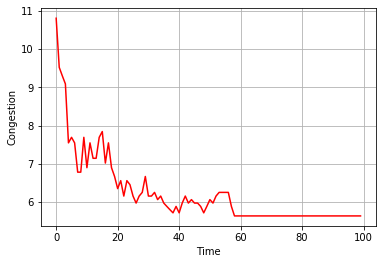

In [19]:
plt.plot(df["time"], df["congestion_index"], 'r')
plt.xlabel("Time")
plt.ylabel("Congestion")
plt.grid(True)
plt.show()

# Gráfica de la velocidad promedio vs tiempo

* Debido a la alta congestión vehícular, la velocidad promedio es baja; conforme se reduce la congestión vehícular la rápidez promedio comienza a aumentar.

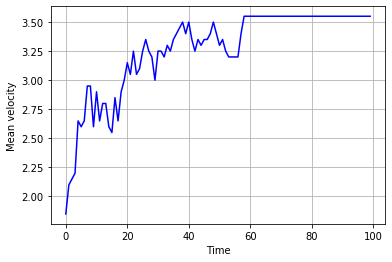

In [20]:
plt.plot(df["time"], df["avg_velocity"], 'b')
plt.xlabel("Time")
plt.ylabel("Mean velocity")
plt.grid(True)
plt.show()

# Distribución de tráfico

* La distribución de tráfico es mayormente media. 

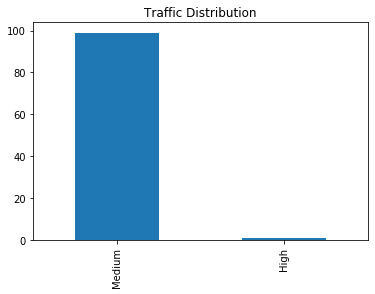

In [14]:
df["traffic_level"].value_counts().plot(kind='bar')
plt.title("Traffic Distribution")
plt.show()

# Matriz de correlación

* El coeficiente $a_{12} = a_{21} \approx -1$, lo que indica una correlación inversa entre la velocidad y el tráfico. A mayor tráfico, menor velocidad; a menor tráfico, mayor velocidad.

In [17]:
df[["avg_velocity", "congestion_index"]].corr()

,avg_velocity,congestion_index
avg_velocity,1.000000,-0.981732
congestion_index,-0.981732,1.000000
